In [24]:
import pandas as pd
import numpy as np
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
!wget = $data

--2026-10-02 12:48:57--  http://=/
Resolving = (=)... failed: Name or service not known.
wget: unable to resolve host address ‘=’
--2026-10-02 12:48:57--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.1’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.06s   

2026-10-02 12:48:57 (9.98 MB/s) - ‘car_fuel_efficiency_2026.csv.1’ saved [635180/635180]

FINISHED --2026-10-02 12:48:57--
Total wall clock time: 0.4s
Downloaded: 1 files, 620K in 0.06s (9.98 MB/s)


In [25]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [26]:
len(df)

10000

In [27]:
df.dtypes


model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [28]:
df.columns


Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [83]:
base = ['engine_displacement','horsepower','vehicle_weight','model_year']

In [85]:
df_selected = df
df_selected = df_selected [base].values


In [159]:
## Q1

In [160]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [ ]:
## Q2

In [87]:
df.horsepower.mean()

np.float64(254.44601556505535)

In [88]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_test - n_val

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
                  
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [89]:
df.fuel_efficiency_mpg.max()

np.float64(41.2)

In [90]:
df.fuel_efficiency_mpg.min()

np.float64(19.8)

In [91]:
df.fuel_efficiency_mpg.unique()

array([31.9, 31.3, 27.5, 28.5, 31. , 31.2, 26.8, 30.2, 30.9, 31.4, 30.4,
       32.8, 35.4, 29.7, 30.1, 28. , 32.7, 26.6, 31.5, 33.8, 28.6, 30.7,
       36.9, 24.1, 25.3, 29.5, 28.2, 33.5, 27.6, 26.4, 35.2, 28.4, 29.2,
       23.8, 37.1, 24.4, 33.2, 36.6, 24.5, 29.6, 33.6, 27.1, 35.8, 36.7,
       35.6, 23.5, 31.6, 27.3, 33. , 33.9, 28.9, 31.7, 33.1, 28.7, 24.3,
       23.2, 34.3, 30.8, 26.5, 26.9, 28.8, 30.6, 26.2, 35.7, 31.1, 29.3,
       29.8, 34.6, 25. , 26.3, 30.5, 26.1, 29.4, 25.8, 34. , 29.9, 32.3,
       35.3, 34.2, 25.9, 27.7, 26.7, 30. , 34.4, 33.7, 35. , 34.5, 34.8,
       25.6, 32.5, 26. , 31.8, 27.8, 32. , 33.3, 27.9, 27.4, 28.3, 32.2,
       37.2, 30.3, 22.3, 35.9, 28.1, 39.1, 25.2, 27.2, 38.4, 24.8, 29. ,
       25.7, 36.8, 32.4, 25.4, 24.7, 33.4, 29.1, 24.2, 22.1, 36.2, 23.3,
       32.1, 23.4, 25.5, 32.9, 23.7, 25.1, 24.6, 32.6, 37.4, 27. , 34.1,
       35.5, 36.3, 23.6, 24.9, 22.7, 37.9, 23.9, 34.9, 36. , 22.4, 21.9,
       23.1, 34.7, 22.8, 37.3, 35.1, 36.4, 24. , 38

In [92]:
df.fuel_efficiency_mpg.nunique()

188

In [93]:
import seaborn as sns

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

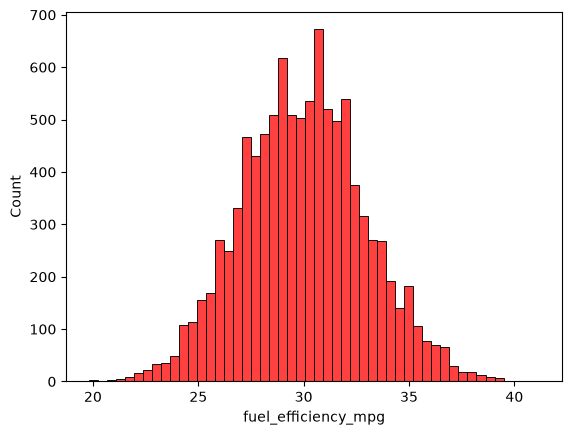

In [94]:
sns.histplot(df.fuel_efficiency_mpg,color ='red', bins = 50)

In [95]:
len(df_train), len(df_val),len(df_test)

(6000, 2000, 2000)

In [96]:
len(df), len(df_train) + len(df_val) + len(df_test)

(10000, 10000)

In [97]:
y_train = df_train.fuel_efficiency_mpg.values
len(y_train)

6000

In [98]:
y_val = df_val.fuel_efficiency_mpg.values
len(y_val)

2000

In [99]:
y_test = df_test.fuel_efficiency_mpg.values
len(y_test)

2000

In [100]:
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [101]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2026 - df.model_year
    feature = base + ['age']            
    df_num = df[feature]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [102]:
def rmse(y,y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [106]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [107]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)


np.float64(6.950453076353539)

In [110]:
df_train.horsepower.mean()

np.float64(254.46338337605272)

In [111]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2026 - df.model_year
    feature = base + ['age']            
    df_num = df[feature]
    df_num = df_num.fillna(df_train.horsepower.mean())
    X = df_num.values
    return X

In [119]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(6.950453076353539)

In [122]:
def train_linear_regression_reg(X, y, r = 0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [123]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2026 - df.model_year
    feature = base + ['age']            
    df_num = df[feature]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [124]:
for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

0.0 23.484163355827306 6.950453076353539
0.01 -2.4552764083056447e-05 2.20529319475676
0.1 -2.4562764249468787e-05 2.2052931952445123
1 -2.4562299387094786e-05 2.205293199721895
5 -2.4562170212832876e-05 2.2052932196088704
10 -2.456201673937804e-05 2.2052932444754054
100 -2.455893363875128e-05 2.2052936936701024


In [162]:
## Q5

In [163]:
error_score = []
base = ['engine_displacement','horsepower','vehicle_weight']#,'model_year']
for myseed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df)
    n_val = int(0.2 * n)
    n_test = int(0.2 * n)
    n_train = n - n_test - n_val
    
    np.random.seed(myseed)
    idx = np.arange(n)
    np.random.shuffle(idx)
                      
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train : n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    
    def prepare_X(df):
        df = df.copy()
        df['age'] = 2026 - df.model_year
        feature = base + ['age']            
        df_num = df[feature]
        df_num = df_num.fillna(0)
        X = df_num.values
        return X
    
    def rmse(y,y_pred):
        error = y - y_pred
        se = error ** 2
        mse = se.mean()
        return np.sqrt(mse)
    
    def train_linear_regression(X, y):
        ones = np.ones(X.shape[0])
        X = np.column_stack([ones, X])
    
        XTX = X.T.dot(X)
        XTX_inv = np.linalg.inv(XTX)
        w_full = XTX_inv.dot(X.T).dot(y)
    
        return w_full[0], w_full[1:]
    
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    
    error = rmse(y_val, y_pred)
    
    error_score.append(error)
    print(myseed, error)

print(error_score)
np.std(error_score).round(3)
      

0 2.2392041430508156
1 2.202112821083731
2 2.1634197787530844
3 2.204358876852943
4 2.2018800943317203
5 2.2457851509081364
6 2.2697212079516436
7 2.190794599935368
8 2.216611201694469
9 2.2070365928234295
[np.float64(2.2392041430508156), np.float64(2.202112821083731), np.float64(2.1634197787530844), np.float64(2.204358876852943), np.float64(2.2018800943317203), np.float64(2.2457851509081364), np.float64(2.2697212079516436), np.float64(2.190794599935368), np.float64(2.216611201694469), np.float64(2.2070365928234295)]


np.float64(0.029)

In [ ]:
##Q3

In [168]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_test - n_val

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
                  
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

def prepare_X(df):
    df = df.copy()
    df['age'] = 2026 - df.model_year
    feature = base + ['age']            
    df_num = df[feature]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

def rmse(y,y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse = rmse(y_val, y_pred)
round(rmse,3)

np.float64(2.205)

In [169]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_test - n_val

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
                  
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

def prepare_X(df):
    df = df.copy()
    df['age'] = 2026 - df.model_year
    feature = base + ['age']            
    df_num = df[feature]
    df_num = df_num.fillna(df_train.horsepower.mean())
    X = df_num.values
    return X

def rmse(y,y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse = rmse(y_val, y_pred)
round(rmse,3)

np.float64(2.202)

In [ ]:
##q4

In [ ]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_test - n_val

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)
                  
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

def prepare_X(df):
    df = df.copy()
    df['age'] = 2026 - df.model_year
    feature = base + ['age']            
    df_num = df[feature]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

def rmse(y,y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

In [ ]:
##Q6

In [ ]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - n_test - n_val

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
                  
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train : n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

def prepare_X(df):
    df = df.copy()
    df['age'] = 2026 - df.model_year
    feature = base + ['age']            
    df_num = df[feature]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

def rmse(y,y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop = True)

y_full_train = np.concatenate([y_train, y_val])
                                          
X_train = prepare_X(df_full_train)
w0, w = train_linear_regression_reg(df_full_train, y_full_train,r=0.001)

X_val = prepare_X(df_test)
y_pred = w0 + X_val.dot(w)

rmse = rmse(y_val, y_pred)
print(round(rmse,3))
rmse

In [ ]:
df